# zjazd05 cz2 pandas selekcja

In [8]:
import pandas as pd
import numpy as np

tips = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv')
tips['tip_pct'] = (tips['tip'] / tips['total_bill'] * 100).round(1)
print(f"tips: {tips.shape[0]} wierszy, {tips.shape[1]} kolumn")


tips: 244 wierszy, 8 kolumn


### Ćwiczenie 1: loc i iloc na nowym datasecie

In [3]:
lotniska = pd.DataFrame({
    'miasto': ['Warszawa', 'Kraków', 'Gdańsk', 'Wrocław', 'Katowice',
               'Poznań', 'Rzeszów', 'Łódź', 'Szczecin', 'Bydgoszcz'],
    'kod': ['WAW', 'KRK', 'GDN', 'WRO', 'KTW',
            'POZ', 'RZE', 'LCJ', 'SZZ', 'BZG'],
    'pasazerowie_mln': [18.9, 9.3, 5.7, 3.8, 5.4,
                         2.6, 0.9, 0.3, 0.6, 0.4],
    'linie': [85, 42, 35, 28, 32, 22, 12, 5, 8, 6],
    'region': ['Mazowieckie', 'Małopolskie', 'Pomorskie', 'Dolnośląskie', 'Śląskie',
               'Wielkopolskie', 'Podkarpackie', 'Łódzkie', 'Zachodniopomorskie', 'Kujawsko-Pomorskie']
})
lotniska.index = lotniska['kod']
print(lotniska[['miasto', 'pasazerowie_mln', 'linie', 'region']])

        miasto  pasazerowie_mln  linie              region
kod                                                       
WAW   Warszawa             18.9     85         Mazowieckie
KRK     Kraków              9.3     42         Małopolskie
GDN     Gdańsk              5.7     35           Pomorskie
WRO    Wrocław              3.8     28        Dolnośląskie
KTW   Katowice              5.4     32             Śląskie
POZ     Poznań              2.6     22       Wielkopolskie
RZE    Rzeszów              0.9     12        Podkarpackie
LCJ       Łódź              0.3      5             Łódzkie
SZZ   Szczecin              0.6      8  Zachodniopomorskie
BZG  Bydgoszcz              0.4      6  Kujawsko-Pomorskie


Zadania

1a — iloc (pozycja):

In [4]:
print(lotniska.iloc[:3])

print(lotniska.iloc[4:8, [0, 2]])

print(lotniska.iloc[::-2])

       miasto  kod  pasazerowie_mln  linie       region
kod                                                    
WAW  Warszawa  WAW             18.9     85  Mazowieckie
KRK    Kraków  KRK              9.3     42  Małopolskie
GDN    Gdańsk  GDN              5.7     35    Pomorskie
       miasto  pasazerowie_mln
kod                           
KTW  Katowice              5.4
POZ    Poznań              2.6
RZE   Rzeszów              0.9
LCJ      Łódź              0.3
        miasto  kod  pasazerowie_mln  linie              region
kod                                                            
BZG  Bydgoszcz  BZG              0.4      6  Kujawsko-Pomorskie
LCJ       Łódź  LCJ              0.3      5             Łódzkie
POZ     Poznań  POZ              2.6     22       Wielkopolskie
WRO    Wrocław  WRO              3.8     28        Dolnośląskie
KRK     Kraków  KRK              9.3     42         Małopolskie


1b — loc (etykieta/warunek):

In [ ]:
print(lotniska.loc['KRK'])

print(lotniska.loc[['WAW', 'GDN', 'KTW'], ['miasto', 'linie']])

print(lotniska.loc[lotniska['pasazerowie_mln'] > 5])

print(lotniska.loc[lotniska['linie'] < 20, ['miasto', 'region']])

miasto                  Kraków
kod                        KRK
pasazerowie_mln            9.3
linie                       42
region             Małopolskie
Name: KRK, dtype: object
       miasto  linie
kod                 
WAW  Warszawa     85
GDN    Gdańsk     35
KTW  Katowice     32
       miasto  kod  pasazerowie_mln  linie       region
kod                                                    
WAW  Warszawa  WAW             18.9     85  Mazowieckie
KRK    Kraków  KRK              9.3     42  Małopolskie
GDN    Gdańsk  GDN              5.7     35    Pomorskie
KTW  Katowice  KTW              5.4     32      Śląskie
        miasto              region
kod                               
RZE    Rzeszów        Podkarpackie
LCJ       Łódź             Łódzkie
SZZ   Szczecin  Zachodniopomorskie
BZG  Bydgoszcz  Kujawsko-Pomorskie


1c — łączone:

In [6]:
regiony_m = lotniska[lotniska['region'].str.startswith('M')]
print(f"Liczba lotnisk w regionach na 'M': {len(regiony_m)}")

lotniska['oblozenie'] = (lotniska['pasazerowie_mln'] / lotniska['linie']) * 1000000

top_oblozenie = lotniska.nlargest(3, 'oblozenie')
print("TOP-3 lotniska pod względem obłożenia na linię:")
print(top_oblozenie[['miasto', 'oblozenie']])

Liczba lotnisk w regionach na 'M': 2
TOP-3 lotniska pod względem obłożenia na linię:
       miasto      oblozenie
kod                         
WAW  Warszawa  222352.941176
KRK    Kraków  221428.571429
KTW  Katowice  168750.000000


# Ćwiczenie 2: Filtrowanie — pytania menedżera restauracji

Cel

Menedżer restauracji zadaje Ci pytania. Odpowiadasz kodem.

Kontekst

Pracujesz jako analityk w restauracji. Menedżer przychodzi z pytaniami o dane sprzedażowe. Masz dataset tips — 244 rachunki z informacjami o napiwkach, dniu, porze i grupie.

Pytania menedżera

Runda 1 — Proste filtry:

#"Ile rachunków mieliśmy w piątek?"

#"Ile rachunków złożyły grupy 1-osobowe? A 6-osobowe?"

#"Jaki jest najwyższy rachunek od kobiety?"

In [ ]:
piatki = tips[tips['day'] == 'Fri']
print(f"Liczba rachunków w piątek: {len(piatki)}")

grupy_1 = len(tips[tips['size'] == 1])
grupy_6 = len(tips[tips['size'] == 6])
print(f"Liczba grup 1-osobowych: {grupy_1}")
print(f"Liczba grup 6-osobowych: {grupy_6}")

max_kobieta = tips[tips['sex'] == 'Female']['total_bill'].max()
print(f"Najwyższy rachunek od kobiety: {max_kobieta}")

Liczba rachunków w piątek: 19
Liczba grup 1-osobowych: 4
Liczba grup 6-osobowych: 4
Najwyższy rachunek od kobiety: 44.3


Runda 2 — Łączone warunki (AND, OR):

In [11]:
weekend_mask = (tips['sex'] == 'Male') & \
               (tips['smoker'] == 'No') & \
               (tips['time'] == 'Dinner') & \
               (tips['day'].isin(['Sat', 'Sun']))

ilu_mezczyzn = len(tips[weekend_mask])
print(f"Liczba niepalących mężczyzn w weekend na obiedzie: {ilu_mezczyzn}")

sr_rachunek = tips[(tips['size'] >= 4) & (tips['day'] == 'Thur')]['total_bill'].mean()
print(f"Średni rachunek dla grup 4+ w czwartek: {sr_rachunek:.2f}$")

podejrzani = tips[(tips['tip_pct'] > 25) & (tips['total_bill'] < 10)]
print(f"Liczba 'podejrzanie hojnych' klientów: {len(podejrzani)}")

print(podejrzani)

Liczba niepalących mężczyzn w weekend na obiedzie: 75
Średni rachunek dla grup 4+ w czwartek: 31.34$
Liczba 'podejrzanie hojnych' klientów: 4
     total_bill   tip     sex smoker   day    time  size  tip_pct
67         3.07  1.00  Female    Yes   Sat  Dinner     1     32.6
149        7.51  2.00    Male     No  Thur   Lunch     2     26.6
172        7.25  5.15    Male    Yes   Sun  Dinner     2     71.0
178        9.60  4.00  Female    Yes   Sun  Dinner     2     41.7


Runda 3 — isin, between, query:

In [12]:
weekend_range = tips[tips['day'].isin(['Sat', 'Sun']) & tips['total_bill'].between(15, 30)]
print(f"Liczba rachunków (weekend, 15-30$): {len(weekend_range)}")

query_string = "day in ['Sat', 'Sun'] and 15 <= total_bill <= 30"
weekend_range_query = tips.query(query_string)
print(f"Liczba (z query): {len(weekend_range_query)}")

srednia = tips['total_bill'].mean()

bonus_query = "sex == 'Male' and smoker == 'No' and time == 'Dinner' and total_bill > @srednia"
wynik_bonus = tips.query(bonus_query)

print(f"Średnia wynosi: {srednia:.2f}$")
print(f"Liczba rachunków powyżej średniej: {len(wynik_bonus)}")

Liczba rachunków (weekend, 15-30$): 93
Liczba (z query): 93
Średnia wynosi: 19.79$
Liczba rachunków powyżej średniej: 33


# Ćwiczenie 3: Analiza filmów 

##  Kontekst

Jesteś analitykiem w firmie streamingowej. Dyrektor chce raport: które filmy kupować do katalogu? Masz dane o 20 filmach — budżet, przychód, ocena, gatunek. Twoim zadaniem jest znaleźć wzorce.

In [13]:
filmy = pd.DataFrame({
    'tytul': ['Incepcja', 'Parasite', 'Avengers: Endgame', 'Joker', 'Coco',
              'Get Out', 'Dune', 'Whiplash', 'Mad Max: Fury Road', 'Spider-Man: No Way Home',
              'The Batman', 'Everything Everywhere', 'Oppenheimer', 'Barbie', 'La La Land',
              'Blade Runner 2049', 'Knives Out', '1917', 'Jojo Rabbit', 'Midsommar'],
    'rok': [2010, 2019, 2019, 2019, 2017,
            2017, 2021, 2014, 2015, 2021,
            2022, 2022, 2023, 2023, 2016,
            2017, 2019, 2019, 2019, 2019],
    'gatunek': ['Sci-Fi', 'Thriller', 'Akcja', 'Dramat', 'Animacja',
                'Horror', 'Sci-Fi', 'Dramat', 'Akcja', 'Akcja',
                'Akcja', 'Sci-Fi', 'Dramat', 'Komedia', 'Musical',
                'Sci-Fi', 'Kryminał', 'Wojenny', 'Komedia', 'Horror'],
    'budzet_mln': [160, 11, 356, 55, 175,
                   4.5, 165, 3.3, 150, 200,
                   185, 25, 100, 145, 30,
                   150, 40, 95, 14, 9],
    'przychod_mln': [836, 258, 2798, 1074, 807,
                     255, 407, 49, 380, 1916,
                     771, 141, 952, 1442, 447,
                     259, 311, 384, 90, 48],
    'ocena_imdb': [8.8, 8.5, 8.4, 8.4, 8.4,
                   7.7, 8.0, 8.5, 8.1, 8.2,
                   7.8, 7.8, 8.3, 6.8, 8.0,
                   8.0, 7.9, 8.3, 7.9, 7.1]
})
filmy['roi'] = (filmy['przychod_mln'] / filmy['budzet_mln']).round(1)
print(filmy[['tytul', 'gatunek', 'budzet_mln', 'przychod_mln', 'roi', 'ocena_imdb']])

                      tytul   gatunek  budzet_mln  przychod_mln   roi  \
0                  Incepcja    Sci-Fi       160.0           836   5.2   
1                  Parasite  Thriller        11.0           258  23.5   
2         Avengers: Endgame     Akcja       356.0          2798   7.9   
3                     Joker    Dramat        55.0          1074  19.5   
4                      Coco  Animacja       175.0           807   4.6   
5                   Get Out    Horror         4.5           255  56.7   
6                      Dune    Sci-Fi       165.0           407   2.5   
7                  Whiplash    Dramat         3.3            49  14.8   
8        Mad Max: Fury Road     Akcja       150.0           380   2.5   
9   Spider-Man: No Way Home     Akcja       200.0          1916   9.6   
10               The Batman     Akcja       185.0           771   4.2   
11    Everything Everywhere    Sci-Fi        25.0           141   5.6   
12              Oppenheimer    Dramat       100.0  

3a: Eksploracja i rankingi

In [14]:
top_przychody = filmy.nlargest(5, 'przychod_mln')
print("TOP-5 pod względem przychodu:")
print(top_przychody[['tytul', 'przychod_mln']])

top_roi = filmy.nlargest(5, 'roi')
print("\nTOP-5 pod względem ROI:")
print(top_roi[['tytul', 'roi']])

top_imdb = filmy.nlargest(5, 'ocena_imdb')
print("\nNajwyżej oceniane filmy (IMDB):")
print(top_imdb[['tytul', 'ocena_imdb']])

tanie_filmy = filmy.loc[filmy['budzet_mln'] < 15, ['tytul', 'budzet_mln', 'przychod_mln']]
print("\nFilmy z budżetem poniżej 15 mln$ i ich zarobki:")
print(tanie_filmy)

TOP-5 pod względem przychodu:
                      tytul  przychod_mln
2         Avengers: Endgame          2798
9   Spider-Man: No Way Home          1916
13                   Barbie          1442
3                     Joker          1074
12              Oppenheimer           952

TOP-5 pod względem ROI:
         tytul   roi
5      Get Out  56.7
1     Parasite  23.5
3        Joker  19.5
14  La La Land  14.9
7     Whiplash  14.8

Najwyżej oceniane filmy (IMDB):
               tytul  ocena_imdb
0           Incepcja         8.8
1           Parasite         8.5
7           Whiplash         8.5
2  Avengers: Endgame         8.4
3              Joker         8.4

Filmy z budżetem poniżej 15 mln$ i ich zarobki:
          tytul  budzet_mln  przychod_mln
1      Parasite        11.0           258
5       Get Out         4.5           255
7      Whiplash         3.3            49
18  Jojo Rabbit        14.0            90
19    Midsommar         9.0            48


3b: Pytania dyrektora

In [15]:
akcja = filmy[filmy['gatunek'] == 'Akcja']
ile_akcja = len(akcja)
sredni_roi_akcja = akcja['roi'].mean()

print(f"Filmy Akcji: {ile_akcja}, Średni ROI: {sredni_roi_akcja:.2f}")

perelki = filmy.query("ocena_imdb >= 8.0 and budzet_mln < 50")
print("\nNasze 'perełki' (wysoka jakość, niski koszt):")
print(perelki[['tytul', 'ocena_imdb', 'budzet_mln']])

print("\nŚredni ROI per gatunek (pętla for):")
unikalne_gatunki = filmy['gatunek'].unique()

for g in unikalne_gatunki:
    sredni_roi = filmy[filmy['gatunek'] == g]['roi'].mean()
    print(f"{g}: {sredni_roi:.2f}")

wnioski_df = filmy.query("2019 <= rok <= 2023 and roi > 5")
print("\nFilmy 2019-2023 z ROI > 5:")
print(wnioski_df[['tytul', 'gatunek', 'roi']])

Filmy Akcji: 4, Średni ROI: 6.05

Nasze 'perełki' (wysoka jakość, niski koszt):
         tytul  ocena_imdb  budzet_mln
1     Parasite         8.5        11.0
7     Whiplash         8.5         3.3
14  La La Land         8.0        30.0

Średni ROI per gatunek (pętla for):
Sci-Fi: 3.75
Thriller: 23.50
Akcja: 6.05
Dramat: 14.60
Animacja: 4.60
Horror: 31.00
Komedia: 8.15
Musical: 14.90
Kryminał: 7.80
Wojenny: 4.00

Filmy 2019-2023 z ROI > 5:
                      tytul   gatunek   roi
1                  Parasite  Thriller  23.5
2         Avengers: Endgame     Akcja   7.9
3                     Joker    Dramat  19.5
9   Spider-Man: No Way Home     Akcja   9.6
11    Everything Everywhere    Sci-Fi   5.6
12              Oppenheimer    Dramat   9.5
13                   Barbie   Komedia   9.9
16               Knives Out  Kryminał   7.8
18              Jojo Rabbit   Komedia   6.4
19                Midsommar    Horror   5.3


3c: Łańcuch operacji (chaining)

In [16]:
wynik = (filmy
    [filmy['ocena_imdb'] >= 7.5]         
    .nlargest(3, 'roi')                       
    [['tytul', 'gatunek', 'roi', 'ocena_imdb']] 
)

print(wynik)

      tytul   gatunek   roi  ocena_imdb
5   Get Out    Horror  56.7         7.7
1  Parasite  Thriller  23.5         8.5
3     Joker    Dramat  19.5         8.4


# Ćwiczenie 4: Segmentacja filmów + wizualizacja + commit

Cel

Podziel filmy na segmenty i zwizualizuj wyniki. Zapisz pracę na GitHubie.

Zadanie

4a: Segmentacja

In [17]:
warunki = [
    (filmy['roi'] > 10),
    (filmy['roi'] > 3)
]

etykiety = ['Hit', 'Zyskowny']

filmy['segment'] = np.select(warunki, etykiety, default='Przeciętny')

print("Liczba filmów w segmentach:")
print(filmy['segment'].value_counts())

print("\nŚrednia ocena IMDB w zależności od segmentu:")
print(filmy.groupby('segment')['ocena_imdb'].mean().round(2))

Liczba filmów w segmentach:
segment
Zyskowny      12
Hit            5
Przeciętny     3
Name: count, dtype: int64

Średnia ocena IMDB w zależności od segmentu:
segment
Hit           8.22
Przeciętny    8.03
Zyskowny      7.98
Name: ocena_imdb, dtype: float64


4b: Wizualizacja

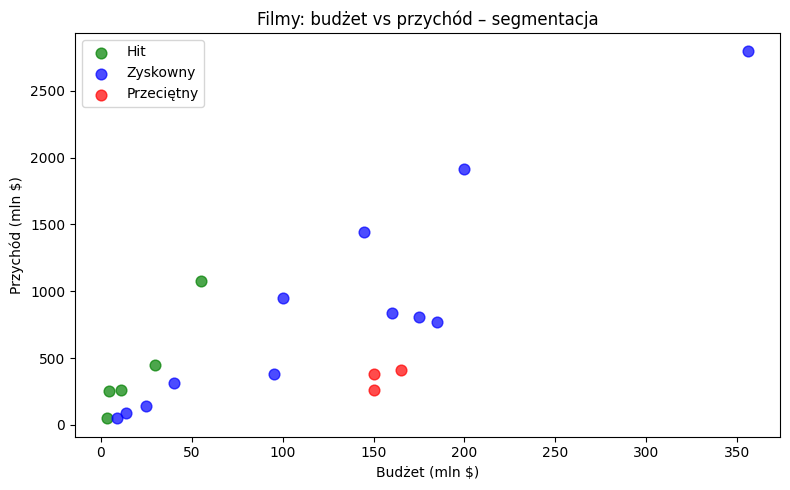

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
kolory = {'Hit': 'green', 'Zyskowny': 'blue', 'Przeciętny': 'red'}

for seg, kolor in kolory.items():
    dane = filmy[filmy['segment'] == seg]
    ax.scatter(dane['budzet_mln'], dane['przychod_mln'], 
               c=kolor, label=seg, s=60, alpha=0.7)

ax.set_xlabel('Budżet (mln $)')
ax.set_ylabel('Przychód (mln $)')
ax.set_title('Filmy: budżet vs przychód – segmentacja')
ax.legend()
plt.tight_layout()
plt.show()

4c: Wniosek dla dyrektora

## REKOMENDACJA:
#Zdecydowanie rekomenduję strategię opartą na inwestowaniu w "tanie perełki" (budżet < 50 mln $).

#Dane pokazują, że filmy te (np. gatunki Thriller czy Dramat) osiągają znacznie wyższy 

#średni zwrot z inwestycji (ROI > 10) oraz wyższe oceny IMDB niż drogie blockbustery.

#Blockbustery generują co prawda najwyższe przychody całkowite, ale ich ROI jest relatywnie niskie, co przy ogromnych kosztach produkcji drastycznie zwiększa ryzyko finansowe.